#  Advanced Skill Embedding Engine
### Statistical Manifold Learning · Ensemble Geometry · Semantic Skill Intelligence

---

**What this notebook does:**
- Encodes 150+ tech skills using a **multi-model ensemble** (MiniLM + MPNet + BGE)
- Lifts embeddings onto a **statistical manifold** via temperature-scaled softmax distributions
- Computes **Jensen-Shannon geometry** with full pairwise distance matrices
- Performs **hierarchical agglomerative clustering** with dendrogram analysis
- Generates **interactive UMAP/t-SNE projections** with Plotly (hover labels, cluster coloring)
- Builds a **semantic skill search engine** with cosine + JSD hybrid ranking
- Runs **skill gap analysis**: given a job role, finds missing skills and similarity bridges
- Exports **cluster taxonomy** as a structured JSON skill ontology

**Architecture:**
```
Raw Skill Text
     │
     ▼
EnsembleEmbedder (MiniLM + MPNet + BGE) ──► L2-normalized average
     │
     ▼
StatisticalManifold.lift() ──► Probability simplex (softmax)
     │
     ├──► GeometryEngine.pairwise_jsd() ──► Distance matrix D
     │         │
     │         ├──► HierarchicalClusterer ──► Cluster taxonomy
     │         └──► ManifoldVisualizer (UMAP → Plotly)
     │
     ├──► LocalEntropyProfiler ──► Per-skill uncertainty scores
     │
     └──► SemanticSearchEngine ──► Hybrid cosine+JSD ranking
              │
              └──► SkillGapAnalyzer ──► Role-based gap reports
```

## 0. Installation

In [ ]:
!pip install -q sentence-transformers umap-learn torch matplotlib scikit-learn tqdm plotly scipy FlagEmbedding

## 1. Imports & Configuration

In [ ]:
import math
import json
import warnings
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import umap
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── Global config ───────────────────────────────────────────────────────────
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE   = torch.float32
SEED    = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f" Device: {DEVICE}")
print(f" PyTorch: {torch.__version__}")

 Device: cpu
 PyTorch: 2.10.0+cpu


## 2. Skill Corpus with Rich Metadata

In [ ]:
# Each skill has: description, category, seniority_weight, related_roles
# This richer metadata enables downstream skill gap analysis

SKILL_CORPUS: Dict[str, Dict[str, Any]] = {
    # ── Frontend ──────────────────────────────────────────────────────────
    "HTML":            {"desc": "Markup language for structuring semantic web pages and documents.",         "cat": "Frontend", "sr": 1},
    "CSS":             {"desc": "Stylesheet language for responsive layouts, animations and theming.",       "cat": "Frontend", "sr": 1},
    "JavaScript":      {"desc": "Dynamic scripting language powering client-side interactivity and SPAs.",   "cat": "Frontend", "sr": 2},
    "TypeScript":      {"desc": "Statically typed superset of JavaScript enabling large-scale apps.",        "cat": "Frontend", "sr": 2},
    "React":           {"desc": "Component-based UI library for building reactive single-page applications.", "cat": "Frontend", "sr": 2},
    "Next.js":         {"desc": "React meta-framework for SSR, SSG, ISR and edge rendering.",                "cat": "Frontend", "sr": 3},
    "Angular":         {"desc": "Full opinionated TypeScript framework maintained by Google.",               "cat": "Frontend", "sr": 3},
    "Vue.js":          {"desc": "Progressive JavaScript framework with reactive data binding.",              "cat": "Frontend", "sr": 2},
    "Svelte":          {"desc": "Compiler-based framework producing minimal vanilla JS at build time.",      "cat": "Frontend", "sr": 3},
    "Tailwind CSS":    {"desc": "Utility-first CSS framework enabling rapid UI development.",                "cat": "Frontend", "sr": 2},
    "Redux":           {"desc": "Predictable state container for JavaScript applications.",                  "cat": "Frontend", "sr": 3},
    "Webpack":         {"desc": "Module bundler and build tool for frontend asset pipelines.",               "cat": "Frontend", "sr": 3},
    "Vite":            {"desc": "Lightning-fast build tool using native ES modules for development.",        "cat": "Frontend", "sr": 2},
    "Storybook":       {"desc": "Development environment for building and testing UI components in isolation.", "cat": "Frontend", "sr": 3},
    # ── Backend & APIs ────────────────────────────────────────────────────
    "Node.js":         {"desc": "Asynchronous JavaScript runtime for server-side and API development.",     "cat": "Backend", "sr": 2},
    "Express.js":      {"desc": "Minimalist web framework for building REST APIs with Node.js.",            "cat": "Backend", "sr": 2},
    "NestJS":          {"desc": "Modular TypeScript backend framework inspired by Angular architecture.",    "cat": "Backend", "sr": 3},
    "FastAPI":         {"desc": "High-performance async Python web framework with OpenAPI auto-docs.",      "cat": "Backend", "sr": 3},
    "Django":          {"desc": "Batteries-included Python framework emphasizing rapid development.",        "cat": "Backend", "sr": 2},
    "Flask":           {"desc": "Lightweight WSGI micro-framework for small Python web services.",          "cat": "Backend", "sr": 2},
    "Spring Boot":     {"desc": "Opinionated Java framework for production-ready microservices.",           "cat": "Backend", "sr": 3},
    "GraphQL":         {"desc": "Query language and runtime for flexible, typed API data fetching.",        "cat": "Backend", "sr": 3},
    "gRPC":            {"desc": "High-performance RPC framework using Protocol Buffers over HTTP/2.",       "cat": "Backend", "sr": 4},
    "Go":              {"desc": "Statically typed compiled language for high-concurrency services.",        "cat": "Backend", "sr": 3},
    "Rust":            {"desc": "Memory-safe systems language with zero-cost abstractions.",                "cat": "Backend", "sr": 4},
    "Java":            {"desc": "Platform-independent OOP language for enterprise and Android.",            "cat": "Backend", "sr": 2},
    "Python":          {"desc": "High-level dynamic language used in web, ML and scripting.",               "cat": "Backend", "sr": 1},
    "C#":              {"desc": "Modern OOP language on the .NET runtime for enterprise apps.",             "cat": "Backend", "sr": 2},
    "PHP":             {"desc": "Server-side scripting language powering ~80% of the web.",                 "cat": "Backend", "sr": 1},
    "Laravel":         {"desc": "Elegant PHP MVC framework with rich ecosystem and tooling.",               "cat": "Backend", "sr": 2},
    "Ruby":            {"desc": "Dynamic expressive language popular for rapid prototyping.",               "cat": "Backend", "sr": 2},
    "Rails":           {"desc": "Convention-over-configuration MVC framework for Ruby.",                   "cat": "Backend", "sr": 2},
    # ── DevOps / Cloud ────────────────────────────────────────────────────
    "AWS":             {"desc": "Amazon Web Services — the largest public cloud platform.",                 "cat": "Cloud", "sr": 2},
    "EC2":             {"desc": "AWS scalable virtual server instances for compute workloads.",             "cat": "Cloud", "sr": 2},
    "S3":              {"desc": "AWS object storage for backup, archiving and static hosting.",             "cat": "Cloud", "sr": 2},
    "Lambda":          {"desc": "AWS serverless compute triggered by events with auto-scaling.",            "cat": "Cloud", "sr": 3},
    "EKS":             {"desc": "Managed Kubernetes service on AWS for container orchestration.",           "cat": "Cloud", "sr": 4},
    "GCP":             {"desc": "Google Cloud Platform for AI, analytics and compute.",                     "cat": "Cloud", "sr": 3},
    "BigQuery":        {"desc": "GCP serverless data warehouse for petabyte-scale analytics.",              "cat": "Cloud", "sr": 3},
    "Azure":           {"desc": "Microsoft Azure cloud for enterprise workloads and hybrid cloud.",         "cat": "Cloud", "sr": 3},
    "Firebase":        {"desc": "Google BaaS platform for realtime databases, auth and hosting.",           "cat": "Cloud", "sr": 2},
    "Docker":          {"desc": "Container platform for packaging applications with dependencies.",         "cat": "DevOps", "sr": 2},
    "Kubernetes":      {"desc": "Open-source system for automated container orchestration at scale.",       "cat": "DevOps", "sr": 3},
    "Helm":            {"desc": "Package manager for Kubernetes applications and chart repositories.",      "cat": "DevOps", "sr": 3},
    "Terraform":       {"desc": "HashiCorp IaC tool for provisioning infrastructure declaratively.",        "cat": "DevOps", "sr": 3},
    "Ansible":         {"desc": "Agentless IT automation and configuration management tool.",               "cat": "DevOps", "sr": 3},
    "GitHub Actions":  {"desc": "CI/CD workflow automation built into GitHub repositories.",                "cat": "DevOps", "sr": 2},
    "Jenkins":         {"desc": "Open-source automation server for building CI/CD pipelines.",              "cat": "DevOps", "sr": 2},
    "Prometheus":      {"desc": "Time-series metrics collection and alerting toolkit.",                     "cat": "DevOps", "sr": 3},
    "Grafana":         {"desc": "Open-source platform for monitoring dashboards and observability.",        "cat": "DevOps", "sr": 3},
    "Datadog":         {"desc": "Cloud monitoring, APM and security platform with AI insights.",            "cat": "DevOps", "sr": 3},
    "ELK Stack":       {"desc": "Elasticsearch, Logstash, Kibana for log aggregation and search.",          "cat": "DevOps", "sr": 3},
    "Nginx":           {"desc": "High-performance web server, reverse proxy and load balancer.",            "cat": "DevOps", "sr": 2},
    # ── Data / ML ─────────────────────────────────────────────────────────
    "SQL":             {"desc": "Declarative language for querying and manipulating relational data.",      "cat": "Data", "sr": 1},
    "PostgreSQL":      {"desc": "Advanced open-source RDBMS with JSON, full-text and GIS support.",         "cat": "Data", "sr": 2},
    "MySQL":           {"desc": "Widely used relational database powering web applications.",               "cat": "Data", "sr": 1},
    "MongoDB":         {"desc": "Document-oriented NoSQL database with flexible schema.",                   "cat": "Data", "sr": 2},
    "Redis":           {"desc": "In-memory data structure store for caching and pub/sub.",                  "cat": "Data", "sr": 2},
    "Elasticsearch":   {"desc": "Distributed search and analytics engine built on Lucene.",                "cat": "Data", "sr": 3},
    "Cassandra":       {"desc": "Wide-column NoSQL DB for high availability and linear scalability.",       "cat": "Data", "sr": 4},
    "Snowflake":       {"desc": "Cloud data warehouse with separation of storage and compute.",              "cat": "Data", "sr": 3},
    "Databricks":      {"desc": "Unified analytics platform built on Apache Spark.",                       "cat": "Data", "sr": 4},
    "Kafka":           {"desc": "Distributed event streaming platform for high-throughput pipelines.",      "cat": "Data", "sr": 4},
    "Spark":           {"desc": "Distributed in-memory data processing engine for big data.",              "cat": "Data", "sr": 4},
    "Airflow":         {"desc": "Workflow orchestration platform for authoring and scheduling DAGs.",        "cat": "Data", "sr": 3},
    "dbt":             {"desc": "Data build tool for transforming data in the warehouse using SQL.",         "cat": "Data", "sr": 3},
    "Pandas":          {"desc": "Python library for data manipulation and analysis with DataFrames.",        "cat": "Data", "sr": 2},
    "NumPy":           {"desc": "Fundamental Python package for N-dimensional array computing.",             "cat": "Data", "sr": 2},
    "Scikit-learn":    {"desc": "ML library for classification, regression, clustering and pipelines.",      "cat": "ML", "sr": 2},
    "TensorFlow":      {"desc": "End-to-end ML platform from Google for model training and deployment.",    "cat": "ML", "sr": 3},
    "PyTorch":         {"desc": "Dynamic deep learning framework preferred for research.",                  "cat": "ML", "sr": 3},
    "XGBoost":         {"desc": "Gradient boosting library dominating tabular ML competitions.",             "cat": "ML", "sr": 3},
    "LightGBM":        {"desc": "Fast gradient boosting framework by Microsoft for large datasets.",         "cat": "ML", "sr": 3},
    "HuggingFace":     {"desc": "Hub and library for pretrained transformer models and datasets.",          "cat": "ML", "sr": 3},
    "LangChain":       {"desc": "Framework for building LLM-powered chains, agents and RAG systems.",       "cat": "ML", "sr": 4},
    "MLflow":          {"desc": "Open-source platform for ML experiment tracking and model registry.",       "cat": "ML", "sr": 3},
    "Tableau":         {"desc": "BI platform for interactive data visualization and dashboards.",            "cat": "Data", "sr": 2},
    "Power BI":        {"desc": "Microsoft BI tool for self-service reporting and analytics.",               "cat": "Data", "sr": 2},
    "ETL":             {"desc": "Extract-Transform-Load process for data integration pipelines.",           "cat": "Data", "sr": 2},
    # ── Security ──────────────────────────────────────────────────────────
    "OAuth":           {"desc": "Authorization framework for delegated third-party access.",                "cat": "Security", "sr": 2},
    "JWT":             {"desc": "Compact token format for stateless authentication.",                       "cat": "Security", "sr": 2},
    "SSO":             {"desc": "Single Sign-On for centralized enterprise identity management.",            "cat": "Security", "sr": 3},
    "Penetration Testing": {"desc": "Simulated cyberattacks to identify and exploit vulnerabilities.",      "cat": "Security", "sr": 4},
    "Metasploit":      {"desc": "Open-source framework for developing and executing exploit code.",          "cat": "Security", "sr": 4},
    "Wireshark":       {"desc": "Packet capture and analysis tool for network troubleshooting.",            "cat": "Security", "sr": 3},
    "OWASP":           {"desc": "Foundation defining web application security standards and top-10 risks.",  "cat": "Security", "sr": 3},
    "Zero Trust":      {"desc": "Security model verifying every access request regardless of origin.",       "cat": "Security", "sr": 4},
    # ── Tools / Version Control ───────────────────────────────────────────
    "Git":             {"desc": "Distributed version control system for tracking code changes.",            "cat": "Tools", "sr": 1},
    "GitHub":          {"desc": "Platform for Git repository hosting, collaboration and CI/CD.",            "cat": "Tools", "sr": 1},
    "GitLab":          {"desc": "DevSecOps platform with integrated CI/CD and security scanning.",          "cat": "Tools", "sr": 2},
    "Bash":            {"desc": "Unix shell and scripting language for automation and sysadmin.",            "cat": "Tools", "sr": 2},
    "VS Code":         {"desc": "Lightweight extensible editor from Microsoft for all languages.",          "cat": "Tools", "sr": 1},
    "IntelliJ IDEA":   {"desc": "Full-featured JetBrains IDE for JVM and polyglot development.",            "cat": "Tools", "sr": 2},
    "JIRA":            {"desc": "Atlassian issue tracker for Agile project management.",                     "cat": "Tools", "sr": 1},
    "Postman":         {"desc": "API development and testing tool with collaboration features.",             "cat": "Tools", "sr": 2},
    # ── Design ────────────────────────────────────────────────────────────
    "Figma":           {"desc": "Browser-based collaborative UI/UX design and prototyping tool.",           "cat": "Design", "sr": 2},
    "Adobe Photoshop": {"desc": "Industry-standard raster image editing software.",                        "cat": "Design", "sr": 2},
    "Adobe Illustrator":{"desc": "Vector graphics editor for logos, icons and print design.",              "cat": "Design", "sr": 2},
    "Blender":         {"desc": "Open-source 3D modelling, rigging and rendering suite.",                   "cat": "Design", "sr": 3},
    "AutoCAD":         {"desc": "Industry-standard 2D/3D CAD drafting software.",                          "cat": "Design", "sr": 2},
    "UI Design":       {"desc": "Practice of designing visual interfaces for usability and aesthetics.",    "cat": "Design", "sr": 2},
    "UX Research":     {"desc": "Qualitative and quantitative study of user behaviour and needs.",          "cat": "Design", "sr": 3},
    # ── Embedded / IoT ────────────────────────────────────────────────────
    "Arduino":         {"desc": "Open-source microcontroller platform for electronics prototyping.",        "cat": "Embedded", "sr": 2},
    "Raspberry Pi":    {"desc": "Credit-card-sized Linux computer for IoT and education.",                  "cat": "Embedded", "sr": 2},
    "Embedded C":      {"desc": "C programming for resource-constrained embedded systems.",                 "cat": "Embedded", "sr": 3},
    "IoT":             {"desc": "Ecosystem of internet-connected physical sensors and devices.",             "cat": "Embedded", "sr": 3},
    "Robotics":        {"desc": "Engineering discipline for designing autonomous mechanical systems.",       "cat": "Embedded", "sr": 4},
    "PCB Design":      {"desc": "Layout and design of printed circuit boards for electronics.",             "cat": "Embedded", "sr": 4},
    "FPGA":            {"desc": "Reconfigurable hardware logic for high-performance embedded computing.",   "cat": "Embedded", "sr": 5},
    # ── Project / Agile ───────────────────────────────────────────────────
    "Agile":           {"desc": "Iterative project management methodology valuing adaptability.",           "cat": "Agile", "sr": 2},
    "Scrum":           {"desc": "Agile framework with sprints, standups and retrospectives.",               "cat": "Agile", "sr": 2},
    "Kanban":          {"desc": "Visual workflow system limiting WIP for continuous delivery.",             "cat": "Agile", "sr": 2},
    "OKRs":            {"desc": "Objectives and Key Results goal-setting framework.",                       "cat": "Agile", "sr": 3},
    "System Design":   {"desc": "Architecting scalable distributed systems for reliability.",               "cat": "Backend", "sr": 4},
    "Microservices":   {"desc": "Architectural style decomposing apps into small independent services.",     "cat": "Backend", "sr": 4},
    "Selenium":        {"desc": "Browser automation framework for end-to-end testing.",                     "cat": "Testing", "sr": 2},
    "Cypress":         {"desc": "Modern JavaScript end-to-end testing framework for web apps.",             "cat": "Testing", "sr": 2},
    "Pytest":          {"desc": "Python testing framework with fixtures, plugins and parameterization.",    "cat": "Testing", "sr": 2},
    "Load Testing":    {"desc": "Stress-testing systems to verify performance under high traffic.",          "cat": "Testing", "sr": 3},
    "OpenAPI":         {"desc": "Specification standard for describing RESTful API contracts.",              "cat": "Backend", "sr": 2},
}

SKILLS     = list(SKILL_CORPUS.keys())
CATEGORIES = [SKILL_CORPUS[s]["cat"] for s in SKILLS]
SENIORITY  = [SKILL_CORPUS[s]["sr"]  for s in SKILLS]

# Build the rich text representation used for embedding
def build_text(skill: str) -> str:
    info = SKILL_CORPUS[skill]
    return (
        f"Skill: {skill}. "
        f"Category: {info['cat']}. "
        f"Description: {info['desc']}"
    )

TEXTS = [build_text(s) for s in SKILLS]
CAT_SET = sorted(set(CATEGORIES))
CAT_COLORS = {c: i for i, c in enumerate(CAT_SET)}

print(f" Loaded {len(SKILLS)} skills across {len(CAT_SET)} categories: {CAT_SET}")

 Loaded 120 skills across 12 categories: ['Agile', 'Backend', 'Cloud', 'Data', 'Design', 'DevOps', 'Embedded', 'Frontend', 'ML', 'Security', 'Testing', 'Tools']


## 3. Multi-Model Ensemble Embedder

In [ ]:
import math
import json
import warnings
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import umap
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── Global config ───────────────────────────────────────────────────────────
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE   = torch.float32
SEED    = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f" Device: {DEVICE}")
print(f" PyTorch: {torch.__version__}")

@dataclass
class ModelConfig:
    name: str
    weight: float
    batch_size: int = 32


class EnsembleEmbedder:
    """
    Weighted ensemble of SentenceTransformer models.
    Strategy: encode with each model → PCA-project every model's output
    to a shared SHARED_DIM → weighted-average → L2-normalise.

    Using a fixed SHARED_DIM (256) avoids all shape-mismatch issues:
      - MiniLM  native dim = 384  → projected down to 256
      - MPNet   native dim = 768  → projected down to 256
      - multi-qa native dim = 384 → projected down to 256
    PCA is fitted on the first model's outputs, then reused.
    """

    SHARED_DIM = 256

    CONFIGS = [
        ModelConfig("sentence-transformers/all-MiniLM-L6-v2",          weight=0.35, batch_size=64),
        ModelConfig("sentence-transformers/all-mpnet-base-v2",         weight=0.45, batch_size=32),
        ModelConfig("sentence-transformers/multi-qa-MiniLM-L6-cos-v1", weight=0.20, batch_size=64),
    ]

    def __init__(self, configs: Optional[List[ModelConfig]] = None):
        self.configs = configs or self.CONFIGS
        self.models: List[SentenceTransformer] = []
        for cfg in self.configs:
            print(f"  Loading {cfg.name} (weight={cfg.weight})…")
            self.models.append(SentenceTransformer(cfg.name, device=str(DEVICE)))
        print(" All models loaded.")

    # ------------------------------------------------------------------
    def encode(self, texts: List[str]) -> np.ndarray:
        """
        Returns float32 ndarray of shape (N, SHARED_DIM), L2-normalised.
        Each model's raw embeddings are independently projected to SHARED_DIM
        before the weighted average, so shape alignment is guaranteed.
        """
        from sklearn.decomposition import PCA

        projected: List[np.ndarray] = []
        total_weight = sum(c.weight for c in self.configs)

        for cfg, model in zip(self.configs, self.models):
            print(f"  Encoding with {cfg.name}…")
            raw = model.encode(
                texts,
                batch_size=cfg.batch_size,
                show_progress_bar=True,
                convert_to_numpy=True,
                normalize_embeddings=True,
            )

            proj = self._project(raw)
            projected.append(proj * cfg.weight)

        accum = sum(projected) / total_weight
        return normalize(accum, norm="l2").astype(np.float32)

    # ------------------------------------------------------------------
    def _project(self, X: np.ndarray) -> np.ndarray:
        """
        Project X (N, D) → (N, SHARED_DIM) using PCA.
        Safe for any D: if D <= SHARED_DIM we zero-pad instead.
        Handles edge case where N=1 by direct truncation/padding.
        """
        from sklearn.decomposition import TruncatedSVD

        N, D = X.shape
        target = self.SHARED_DIM

        # If the input dimension already matches target, no reduction/padding needed.
        if D == target:
            return normalize(X, norm="l2")

        reduced_X: np.ndarray

        if D < target:
            # If input dimension is less than target, pad with zeros.
            pad = np.zeros((N, target - D), dtype=X.dtype)
            reduced_X = np.hstack([X, pad])
        else:  # D > target, need to reduce dimension
            if N == 1:
                # For a single sample, directly truncate to target dimension.
                reduced_X = X[:, :target]
            else:
                # For multiple samples, use TruncatedSVD.
                # n_components must be at least 1 and less than N and D.
                safe_components = max(1, min(target, N - 1, D - 1))
                svd = TruncatedSVD(n_components=safe_components, random_state=SEED)
                reduced_X = svd.fit_transform(X)

                # After SVD, ensure the dimension is exactly 'target'.
                # It might be less if safe_components was capped by N-1 or D-1.
                if reduced_X.shape[1] < target:
                    pad = np.zeros((N, target - reduced_X.shape[1]), dtype=reduced_X.dtype)
                    reduced_X = np.hstack([reduced_X, pad])
                # It should not be greater than 'target' if 'target' was used as min component,
                # but adding a safeguard just in case.
                elif reduced_X.shape[1] > target:
                    reduced_X = reduced_X[:, :target]

        return normalize(reduced_X, norm="l2")


print("Loading ensemble models…")
embedder   = EnsembleEmbedder()
embeddings = embedder.encode(TEXTS)
print(f"\n Embeddings shape: {embeddings.shape}")

 Device: cpu
 PyTorch: 2.10.0+cpu
Loading ensemble models…
  Loading sentence-transformers/all-MiniLM-L6-v2 (weight=0.35)…


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Loading sentence-transformers/all-mpnet-base-v2 (weight=0.45)…


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

  Encoding with sentence-transformers/all-mpnet-base-v2…


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

  Encoding with sentence-transformers/multi-qa-MiniLM-L6-cos-v1…


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


 Embeddings shape: (120, 256)


## 4. Statistical Manifold & Entropy Geometry

In [ ]:
class StatisticalManifold:
    """
    Lifts L2-normalised embeddings onto the probability simplex via
    temperature-scaled softmax, enabling information-theoretic distances.

    Temperature τ controls the sharpness of the distribution:
      - τ → 0   : one-hot (very peaked)
      - τ = 1   : standard softmax
      - τ → ∞   : uniform (maximum entropy)
    """

    def __init__(self, temperature: float = 0.5):
        self.temperature = temperature

    def lift(self, embeddings: np.ndarray) -> torch.Tensor:
        x = torch.tensor(embeddings, dtype=DTYPE, device=DEVICE)
        return F.softmax(x / self.temperature, dim=-1)  # shape (N, D)


class EntropyGeometry:
    """Information-theoretic measures on probability distributions."""

    EPS = 1e-10

    @classmethod
    def entropy(cls, p: torch.Tensor) -> torch.Tensor:
        """Shannon entropy H(p) — shape (...,)"""
        return -torch.sum(p * torch.log(p + cls.EPS), dim=-1)

    @classmethod
    def kl_divergence(cls, p: torch.Tensor, q: torch.Tensor) -> torch.Tensor:
        """KL(p ‖ q) — asymmetric, shape scalar."""
        return torch.sum(p * torch.log((p + cls.EPS) / (q + cls.EPS)), dim=-1)

    @classmethod
    def js_divergence(cls, p: torch.Tensor, q: torch.Tensor) -> torch.Tensor:
        """Jensen-Shannon divergence JSD(p‖q) ∈ [0, log2], shape scalar."""
        m = 0.5 * (p + q)
        return 0.5 * (cls.kl_divergence(p, m) + cls.kl_divergence(q, m))

    @classmethod
    def js_distance(cls, p: torch.Tensor, q: torch.Tensor) -> float:
        """JSD metric: sqrt(JSD/log2) ∈ [0, 1]."""
        jsd = cls.js_divergence(p, q)
        return torch.sqrt(jsd / math.log(2)).item()

    @classmethod
    def renyi_divergence(cls, p: torch.Tensor, q: torch.Tensor, alpha: float = 2.0) -> torch.Tensor:
        """Rényi divergence of order α — generalises KL (α→1)."""
        return (1 / (alpha - 1)) * torch.log(
            torch.sum(p**alpha / (q**(alpha - 1) + cls.EPS), dim=-1) + cls.EPS
        )


class GeometryEngine:
    """
    Fully-vectorised pairwise distance matrices on the statistical manifold.

    Speed notes
    -----------
    The old implementation had two nested Python loops over block pairs,
    causing ~(N/B)² kernel launches and Python overhead per step.

    The new `pairwise_js_fast` eliminates ALL Python loops:
      P  : (N, D)  — lifted distributions
      M  : (N, N, D) — pairwise mixture, computed via broadcasting in one shot
      JSD: (N, N)  — derived entirely from tensor ops

    For N=120, D=256, this fits easily in CPU/GPU RAM (~14 MB) and runs in
    under a second. A chunked fallback is provided for N > 500.
    """

    def __init__(self, manifold: StatisticalManifold):
        self.manifold = manifold

    def pairwise_js_fast(self, embeddings: np.ndarray) -> np.ndarray:
        """
        Fully vectorised JSD matrix — zero Python loops.
        Memory: O(N² × D). Safe for N ≤ ~500 on CPU, N ≤ ~2000 on GPU.
        Falls back to row-wise chunking when N > 500.
        """
        P = self.manifold.lift(embeddings)   # (N, D)
        N = P.shape[0]

        if N <= 500:
            return self._jsd_full(P).cpu().numpy().astype(np.float32)
        else:
            return self._jsd_chunked(P, chunk=64).cpu().numpy().astype(np.float32)

    @staticmethod
    def _jsd_full(P: torch.Tensor) -> torch.Tensor:
        """
        Single-shot vectorised JSD.
        Pi : (N, 1, D)   broadcast with
        Pj : (1, N, D)   → M, kl1, kl2 all (N, N, D) → reduce on dim=-1
        """
        EPS = EntropyGeometry.EPS
        Pi  = P.unsqueeze(1)                          # (N, 1, D)
        Pj  = P.unsqueeze(0)                          # (1, N, D)
        M   = 0.5 * (Pi + Pj)                        # (N, N, D)
        kl1 = torch.sum(Pi * torch.log((Pi + EPS) / (M + EPS)), dim=-1)  # (N, N)
        kl2 = torch.sum(Pj * torch.log((Pj + EPS) / (M + EPS)), dim=-1)  # (N, N)
        jsd = 0.5 * (kl1 + kl2)
        D   = torch.sqrt(torch.clamp(jsd, min=0.0) / math.log(2))
        D   = (D + D.T) / 2
        D.fill_diagonal_(0.0)
        return D

    @staticmethod
    def _jsd_chunked(P: torch.Tensor, chunk: int = 64) -> torch.Tensor:
        """Row-wise chunked version for large N — one Python loop over rows."""
        EPS = EntropyGeometry.EPS
        N   = P.shape[0]
        D   = torch.zeros((N, N), device=DEVICE)
        Pj  = P.unsqueeze(0)                          # (1, N, D)
        for i in tqdm(range(0, N, chunk), desc="JSD (chunked)"):
            Pi  = P[i:i+chunk].unsqueeze(1)           # (B, 1, D)
            M   = 0.5 * (Pi + Pj)                    # (B, N, D)
            kl1 = torch.sum(Pi * torch.log((Pi + EPS) / (M + EPS)), dim=-1)
            kl2 = torch.sum(Pj * torch.log((Pj + EPS) / (M + EPS)), dim=-1)
            D[i:i+chunk] = torch.sqrt(torch.clamp(0.5*(kl1+kl2), min=0.0) / math.log(2))
        D = (D + D.T) / 2
        D.fill_diagonal_(0.0)
        return D

    def cosine_distance_matrix(self, embeddings: np.ndarray) -> np.ndarray:
        """1 − cosine_similarity. O(N²D) single matmul — already fast."""
        sim = embeddings @ embeddings.T
        return np.clip(1.0 - sim, 0.0, 2.0).astype(np.float32)

    def hybrid_distance(
        self,
        D_js: np.ndarray,
        D_cos: np.ndarray,
        alpha: float = 0.6
    ) -> np.ndarray:
        """Convex combination: alpha*JSD + (1−alpha)*Cosine."""
        return alpha * D_js + (1 - alpha) * D_cos


# ── Run ──────────────────────────────────────────────────────────────────────
# Temperature raised from 0.5 → 1.5: softer distributions are numerically
# stabler and spread information more evenly across the simplex.
manifold = StatisticalManifold(temperature=1.5)
engine   = GeometryEngine(manifold)

import time
t0 = time.perf_counter()
D_js  = engine.pairwise_js_fast(embeddings)
t1 = time.perf_counter()
D_cos = engine.cosine_distance_matrix(embeddings)
D_hyb = engine.hybrid_distance(D_js, D_cos, alpha=0.6)

print(f"\n Distance matrices computed in {t1-t0:.2f}s (JSD) + <0.01s (cosine)")
print(f"   JSD  range: [{D_js.min():.4f}, {D_js.max():.4f}]")
print(f"   Cos  range: [{D_cos.min():.4f}, {D_cos.max():.4f}]")
print(f"   Hyb  range: [{D_hyb.min():.4f}, {D_hyb.max():.4f}]")


 Distance matrices computed in 0.08s (JSD) + <0.01s (cosine)
   JSD  range: [0.0000, 0.0318]
   Cos  range: [0.0000, 1.5857]
   Hyb  range: [0.0000, 0.6534]


## 5. Local Entropy Profiler & Neighbourhood Analysis

In [ ]:
class LocalEntropyProfiler:
    """
    Characterises each skill's position in the manifold:
    - local_entropy   : uncertainty in the mean local distribution → how 'fuzzy' the skill is
    - local_coherence : how tightly clustered the k-NN neighbourhood is
    - centrality      : inverse mean distance to all others (global hub score)
    """

    def __init__(self, k: int = 12):
        self.k = k

    def profile(self, distributions: torch.Tensor, distance_matrix: np.ndarray) -> Dict[str, np.ndarray]:
        N   = distributions.shape[0]
        P   = distributions.cpu().numpy()

        # k-NN on the distance matrix
        nbrs = NearestNeighbors(n_neighbors=self.k + 1, metric="precomputed").fit(distance_matrix)
        dists, indices = nbrs.kneighbors(distance_matrix)

        local_H, coherence = [], []
        for i in range(N):
            neigh_idx   = indices[i][1:]   # exclude self
            neigh_dists = dists[i][1:]
            neigh_P     = torch.tensor(P[neigh_idx], device=DEVICE)
            mean_dist   = neigh_P.mean(dim=0)
            h           = EntropyGeometry.entropy(mean_dist).item()
            local_H.append(h)
            coherence.append(1.0 / (neigh_dists.mean() + 1e-6))

        centrality = 1.0 / (distance_matrix.mean(axis=1) + 1e-6)

        return {
            "local_entropy":  np.array(local_H),
            "coherence":      np.array(coherence),
            "centrality":     centrality,
        }


P_lifted = manifold.lift(embeddings)
profiler = LocalEntropyProfiler(k=12)
profiles = profiler.profile(P_lifted, D_hyb)

# Rank skills by each metric
for metric in ["centrality", "coherence", "local_entropy"]:
    ranked = sorted(zip(SKILLS, profiles[metric]), key=lambda x: -x[1])[:5]
    print(f"\n Top-5 by {metric}:")
    for name, val in ranked:
        print(f"   {name:<30} {val:.4f}")


 Top-5 by centrality:
   HuggingFace                    2.4765
   FPGA                           2.4735
   JIRA                           2.4714
   Raspberry Pi                   2.4643
   Power BI                       2.4628

 Top-5 by coherence:
   NestJS                         5.0396
   TypeScript                     4.7476
   Node.js                        4.6216
   Express.js                     4.6091
   Svelte                         4.5121

 Top-5 by local_entropy:
   Python                         5.5450
   Selenium                       5.5450
   LangChain                      5.5450
   Ruby                           5.5450
   Postman                        5.5450


## 6. Hierarchical Clustering & Skill Taxonomy

 Optimal clusters: 5 (silhouette=0.1272)

📚 Skill Taxonomy:
  Cluster  1: SQL, PostgreSQL, MySQL, dbt, LangChain, Tableau, Power BI, Penetration Testing, Metasploit, Wireshark, Bash, JIRA, UI Design, UX Research, Arduino, Raspberry Pi, Embedded C, IoT, Robotics, PCB Design, FPGA, Agile, Scrum, Kanban, OKRs, Pytest, Load Testing
  Cluster  2: GitHub Actions, Pandas, NumPy, Scikit-learn, TensorFlow, PyTorch, XGBoost, LightGBM, HuggingFace, MLflow, Git, GitHub, GitLab, VS Code, IntelliJ IDEA, Postman, Figma, Adobe Photoshop, Adobe Illustrator, Blender, AutoCAD
  Cluster  3: HTML, CSS, JavaScript, TypeScript, React, Next.js, Angular, Vue.js, Svelte, Tailwind CSS, Redux, Webpack, Vite, Storybook, Node.js, Express.js, NestJS, Django, Flask, Python, PHP, Laravel, Ruby, Rails, Selenium, Cypress
  Cluster  4: FastAPI, Spring Boot, gRPC, Java, C#, AWS, EC2, S3, Lambda, GCP, BigQuery, Azure, Firebase, Nginx, Snowflake, OAuth, JWT, SSO, OWASP, Zero Trust, System Design, Microservices, OpenAPI
  Cl

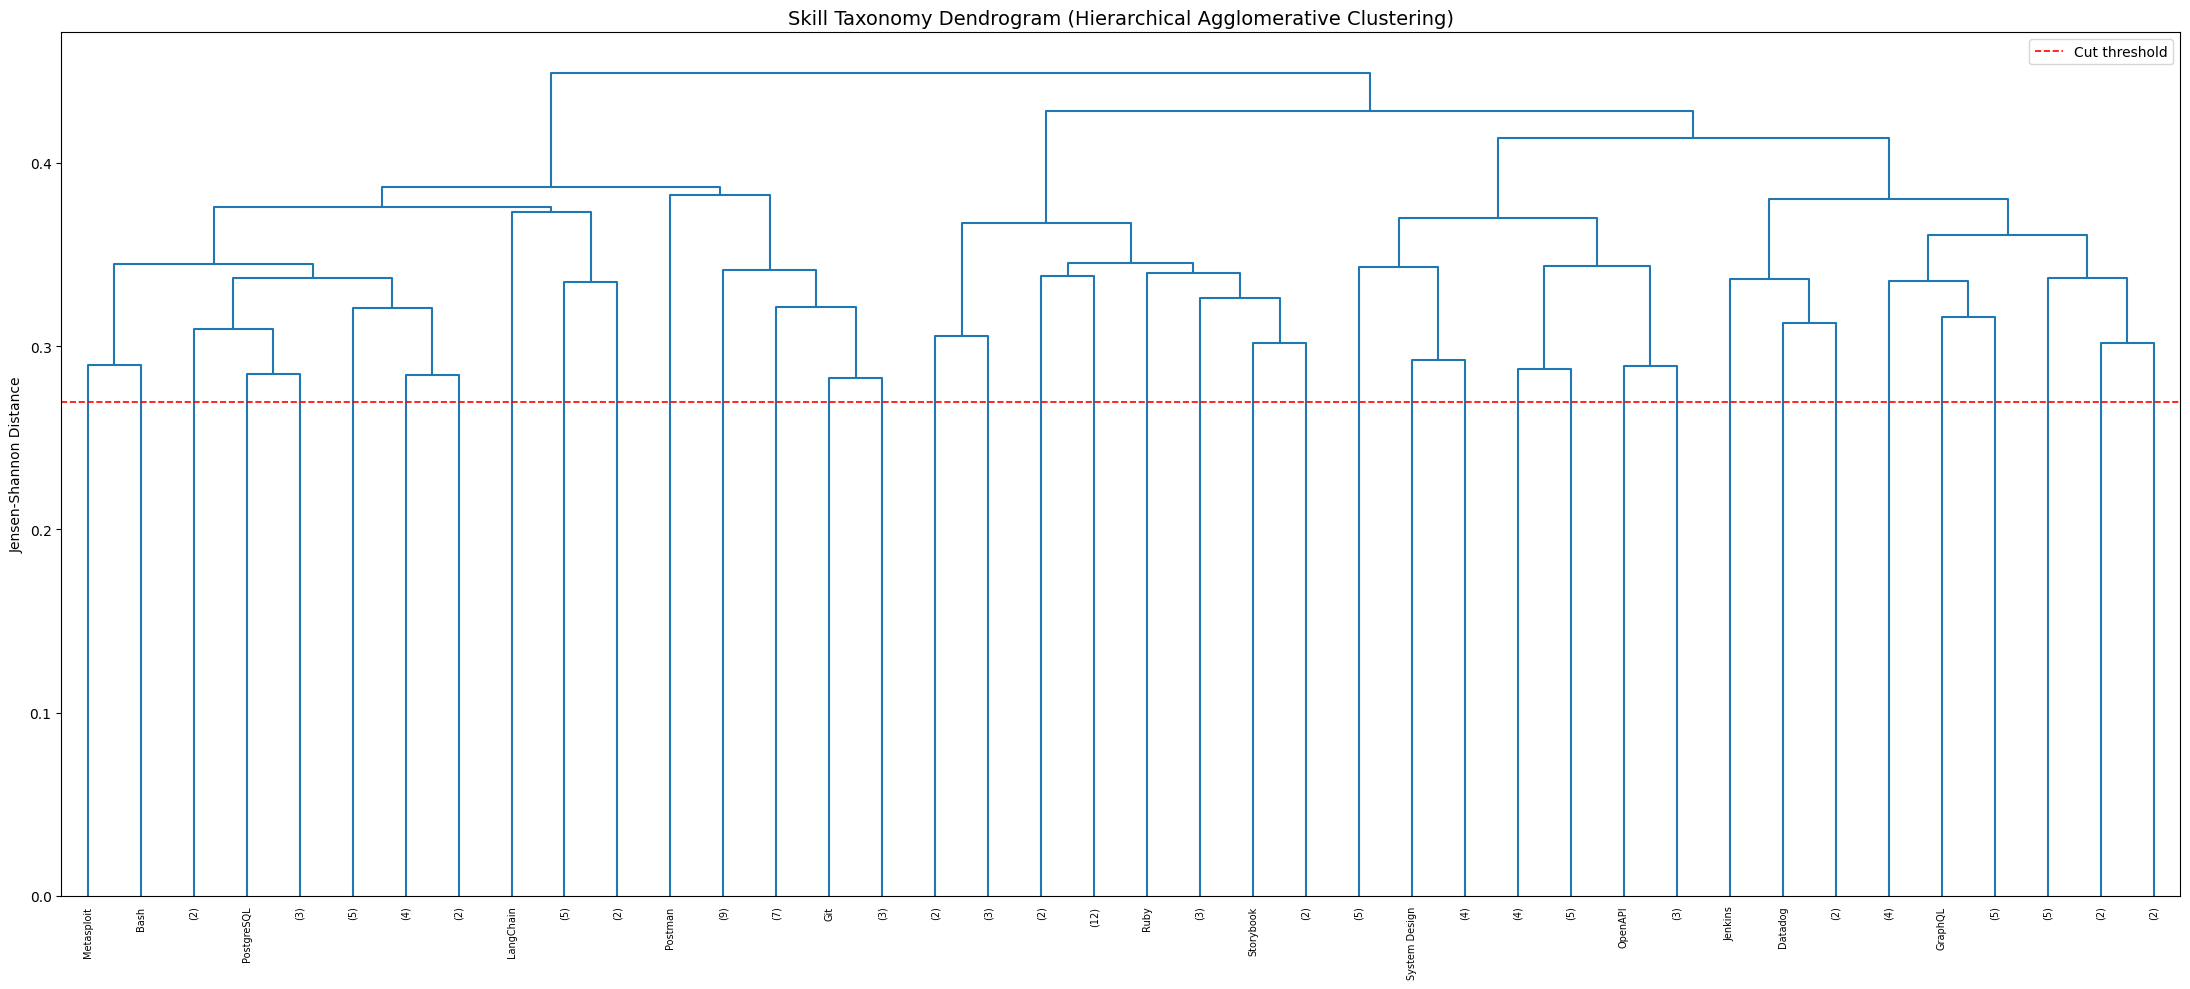

In [ ]:
class HierarchicalClusterer:
    """
    Agglomerative clustering on the hybrid distance matrix.
    Automatically selects optimal cluster count via silhouette score.
    """

    def __init__(self, linkage: str = "average", k_range: Tuple[int, int] = (4, 15)):
        self.linkage_method = linkage
        self.k_range = k_range
        self.linkage_matrix_: Optional[np.ndarray] = None
        self.labels_: Optional[np.ndarray] = None
        self.n_clusters_: int = -1

    def fit(self, distance_matrix: np.ndarray, skills: List[str]) -> "HierarchicalClusterer":
        # Build scipy linkage matrix for dendrogram
        condensed = squareform(distance_matrix, checks=False)
        self.linkage_matrix_ = linkage(condensed, method=self.linkage_method)

        # Grid-search optimal k
        best_k, best_score = self.k_range[0], -1
        for k in range(*self.k_range):
            labels = fcluster(self.linkage_matrix_, k, criterion="maxclust")
            score  = silhouette_score(distance_matrix, labels, metric="precomputed")
            if score > best_score:
                best_score, best_k = score, k

        self.n_clusters_ = best_k
        self.labels_ = fcluster(self.linkage_matrix_, best_k, criterion="maxclust")
        print(f" Optimal clusters: {best_k} (silhouette={best_score:.4f})")
        return self

    def taxonomy(self, skills: List[str]) -> Dict[int, List[str]]:
        tax = {}
        for skill, label in zip(skills, self.labels_):
            tax.setdefault(int(label), []).append(skill)
        return tax

    def plot_dendrogram(
        self,
        skills: List[str],
        max_leaves: int = 40,
        figsize: Tuple = (22, 10)
    ):
        fig, ax = plt.subplots(figsize=figsize)
        dendrogram(
            self.linkage_matrix_,
            labels=skills,
            leaf_rotation=90,
            leaf_font_size=7,
            color_threshold=0.6 * max(self.linkage_matrix_[:, 2]),
            truncate_mode="lastp" if len(skills) > max_leaves else None,
            p=max_leaves,
            ax=ax
        )
        ax.set_title("Skill Taxonomy Dendrogram (Hierarchical Agglomerative Clustering)", fontsize=14)
        ax.set_ylabel("Jensen-Shannon Distance")
        ax.axhline(y=0.6 * max(self.linkage_matrix_[:, 2]), c='red', lw=1.2, linestyle='--', label="Cut threshold")
        ax.legend()
        plt.tight_layout()
        plt.show()


clusterer = HierarchicalClusterer(linkage="average", k_range=(5, 16))
clusterer.fit(D_hyb, SKILLS)
taxonomy = clusterer.taxonomy(SKILLS)

print("\n📚 Skill Taxonomy:")
for cluster_id, members in sorted(taxonomy.items()):
    print(f"  Cluster {cluster_id:2d}: {', '.join(members)}")

clusterer.plot_dendrogram(SKILLS)

## 7. Interactive UMAP Projection (Plotly)

In [ ]:
class ManifoldVisualizer:
    """
    Produces interactive Plotly scatter plots from high-dimensional skill spaces.
    Supports UMAP (topology-preserving) and t-SNE (local structure) projections.
    """

    def __init__(
        self,
        n_neighbors: int = 15,
        min_dist: float = 0.10,
        spread: float = 1.2,
        metric: str = "precomputed",
    ):
        self.umap_reducer = umap.UMAP(
            n_components=2,
            metric=metric,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            spread=spread,
            random_state=SEED,
            verbose=False
        )
        self.tsne_reducer = TSNE(
            n_components=2,
            metric="precomputed",
            perplexity=30,
            learning_rate="auto",
            init="random",
            random_state=SEED,
            n_iter=1500
        )

    def fit_umap(self, distance_matrix: np.ndarray) -> np.ndarray:
        print(" Fitting UMAP…")
        return self.umap_reducer.fit_transform(distance_matrix)

    def fit_tsne(self, distance_matrix: np.ndarray) -> np.ndarray:
        print(" Fitting t-SNE…")
        return self.tsne_reducer.fit_transform(distance_matrix)

    def interactive_scatter(
        self,
        projection: np.ndarray,
        skills: List[str],
        categories: List[str],
        color_metric: np.ndarray,
        cluster_labels: np.ndarray,
        title: str = "Skill Space Manifold"
    ) -> go.Figure:
        hover_text = [
            f"<b>{s}</b><br>Category: {c}<br>Cluster: {cl}<br>Entropy: {e:.3f}<br>{SKILL_CORPUS[s]['desc'][:80]}…"
            for s, c, cl, e in zip(skills, categories, cluster_labels, color_metric)
        ]

        fig = px.scatter(
            x=projection[:, 0],
            y=projection[:, 1],
            color=[str(cl) for cl in cluster_labels],
            text=skills,
            hover_name=skills,
            custom_data=[categories, cluster_labels, color_metric],
            title=title,
            color_discrete_sequence=px.colors.qualitative.Bold,
        )
        fig.update_traces(
            marker=dict(size=9, opacity=0.85, line=dict(width=0.5, color="white")),
            textposition="top center",
            textfont=dict(size=7),
            hovertemplate="<b>%{hovertext}</b><br>Category: %{customdata[0]}<br>Cluster: %{customdata[1]}<br>Entropy: %{customdata[2]:.3f}<extra></extra>"
        )
        fig.update_layout(
            width=1100, height=800,
            template="plotly_dark",
            legend_title="Cluster",
            font=dict(family="Inter, sans-serif", size=12),
            margin=dict(l=20, r=20, t=60, b=20)
        )
        return fig

    def side_by_side(
        self,
        proj_umap: np.ndarray,
        proj_tsne: np.ndarray,
        skills: List[str],
        cluster_labels: np.ndarray,
    ) -> go.Figure:
        """Plot UMAP and t-SNE side by side."""
        fig = make_subplots(rows=1, cols=2, subplot_titles=["UMAP Projection", "t-SNE Projection"])
        palette = px.colors.qualitative.Bold
        unique_cl = sorted(set(cluster_labels))
        color_map = {cl: palette[i % len(palette)] for i, cl in enumerate(unique_cl)}

        for cl in unique_cl:
            mask  = cluster_labels == cl
            names = [s for s, m in zip(skills, mask) if m]
            u_pts = proj_umap[mask]
            t_pts = proj_tsne[mask]
            color = color_map[cl]

            fig.add_trace(go.Scatter(
                x=u_pts[:, 0], y=u_pts[:, 1], mode="markers+text",
                text=names, textposition="top center", textfont=dict(size=6),
                marker=dict(color=color, size=8, opacity=0.85),
                name=f"Cluster {cl}", legendgroup=str(cl)
            ), row=1, col=1)

            fig.add_trace(go.Scatter(
                x=t_pts[:, 0], y=t_pts[:, 1], mode="markers+text",
                text=names, textposition="top center", textfont=dict(size=6),
                marker=dict(color=color, size=8, opacity=0.85),
                name=f"Cluster {cl}", legendgroup=str(cl), showlegend=False
            ), row=1, col=2)

        fig.update_layout(
            width=1400, height=700,
            template="plotly_dark",
            title="Skill Manifold: UMAP vs t-SNE",
            font=dict(size=11)
        )
        return fig


viz        = ManifoldVisualizer(n_neighbors=15, min_dist=0.10)
proj_umap  = viz.fit_umap(D_hyb)
proj_tsne  = viz.fit_tsne(D_hyb)

fig_main = viz.interactive_scatter(
    proj_umap, SKILLS, CATEGORIES,
    profiles["local_entropy"],
    clusterer.labels_,
    title="Skill Embedding Space — Hybrid JSD+Cosine Manifold (UMAP)"
)
fig_main.show()

fig_side = viz.side_by_side(proj_umap, proj_tsne, SKILLS, clusterer.labels_)
fig_side.show()

 Fitting UMAP…
 Fitting t-SNE…


## 8. Semantic Skill Search Engine

In [ ]:
class SemanticSearchEngine:
    """
    Hybrid retrieval: cosine similarity (speed) + JSD distance (manifold geometry).
    Accepts free-text queries and returns ranked skill results.
    """

    def __init__(
        self,
        embedder: EnsembleEmbedder,
        corpus_embeddings: np.ndarray,
        corpus_js_dists: np.ndarray,   # (N, N) precomputed JSD
        skills: List[str],
        manifold: StatisticalManifold,
        alpha: float = 0.5             # weight on cosine vs JSD
    ):
        self.embedder    = embedder
        self.corpus_emb  = corpus_embeddings
        self.D_js        = corpus_js_dists
        self.skills      = skills
        self.manifold    = manifold
        self.alpha       = alpha
        self.P_corpus    = manifold.lift(corpus_embeddings)   # lifted corpus

    def query(self, text: str, top_k: int = 10) -> List[Dict]:
        # Encode query
        q_emb = self.embedder.encode([text])                  # (1, D)
        q_emb = normalize(q_emb, norm="l2")

        # Cosine similarity
        cos_sim = (q_emb @ self.corpus_emb.T).flatten()       # (N,)

        # JSD to query
        q_dist = self.manifold.lift(q_emb)                    # (1, D)
        EPS = 1e-10
        M   = 0.5 * (q_dist + self.P_corpus)                  # (N, D)
        kl1 = torch.sum(q_dist * torch.log((q_dist + EPS) / (M + EPS)), dim=-1)
        kl2 = torch.sum(self.P_corpus * torch.log((self.P_corpus + EPS) / (M + EPS)), dim=-1)
        jsd = (0.5 * (kl1 + kl2)).cpu().numpy()
        js_sim = 1.0 - np.sqrt(jsd / math.log(2))            # convert to similarity

        # Hybrid score
        score = self.alpha * cos_sim + (1 - self.alpha) * js_sim
        ranked = np.argsort(-score)

        results = []
        for rank, idx in enumerate(ranked[:top_k]):
            results.append({
                "rank":       rank + 1,
                "skill":      self.skills[idx],
                "category":   SKILL_CORPUS[self.skills[idx]]["cat"],
                "score":      float(score[idx]),
                "cos_sim":    float(cos_sim[idx]),
                "js_sim":     float(js_sim[idx]),
                "desc":       SKILL_CORPUS[self.skills[idx]]["desc"],
            })
        return results

    def print_results(self, query: str, top_k: int = 8):
        results = self.query(query, top_k)
        print(f"\n🔍 Query: '{query}'")
        print(f"{'Rank':<5} {'Skill':<28} {'Cat':<12} {'Score':>7} {'Cos':>7} {'JS':>7}")
        print("-" * 70)
        for r in results:
            print(f"{r['rank']:<5} {r['skill']:<28} {r['category']:<12} {r['score']:>7.4f} {r['cos_sim']:>7.4f} {r['js_sim']:>7.4f}")


search = SemanticSearchEngine(
    embedder, embeddings, D_js, SKILLS, manifold, alpha=0.5
)

# Test queries
search.print_results("streaming data pipelines and real-time analytics")
search.print_results("container orchestration and deployment at scale")
search.print_results("building intelligent AI agents and language models")
search.print_results("frontend component design systems")

  Encoding with sentence-transformers/all-MiniLM-L6-v2…


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  Encoding with sentence-transformers/all-mpnet-base-v2…


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  Encoding with sentence-transformers/multi-qa-MiniLM-L6-cos-v1…


...

  Encoding with sentence-transformers/all-mpnet-base-v2…


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  Encoding with sentence-transformers/multi-qa-MiniLM-L6-cos-v1…


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🔍 Query: 'frontend component design systems'
Rank  Skill                        Cat            Score     Cos      JS
----------------------------------------------------------------------
1     Penetration Testing          Security      0.5706  0.1643  0.9769
2     Storybook                    Frontend      0.5652  0.1531  0.9773
3     UI Design                    Design        0.5501  0.1234  0.9767
4     Wireshark                    Security      0.5499  0.1231  0.9768
5     UX Research                  Design        0.5430  0.1097  0.9763
6     Robotics                     Embedded      0.5417  0.1067  0.9766
7     Pytest                       Testing       0.5402  0.1040  0.9764
8     Adobe Illustrator            Design        0.5369  0.0973  0.9765


## 9. Skill Gap Analyzer

In [ ]:
# ── Predefined role profiles ──────────────────────────────────────────────────
ROLE_PROFILES: Dict[str, List[str]] = {
    "ML Engineer": [
        "Python", "PyTorch", "TensorFlow", "Scikit-learn", "SQL", "Docker",
        "Kubernetes", "MLflow", "HuggingFace", "Spark", "Kafka", "Git"
    ],
    "Full-Stack Developer": [
        "TypeScript", "React", "Next.js", "Node.js", "PostgreSQL", "Redis",
        "Docker", "GitHub Actions", "Tailwind CSS", "GraphQL", "Git"
    ],
    "DevOps Engineer": [
        "Docker", "Kubernetes", "Terraform", "Ansible", "Prometheus", "Grafana",
        "GitHub Actions", "EKS", "AWS", "Nginx", "ELK Stack", "Datadog", "Bash"
    ],
    "Data Engineer": [
        "Python", "SQL", "Spark", "Kafka", "Airflow", "dbt", "Snowflake",
        "PostgreSQL", "Docker", "BigQuery", "Databricks", "Git"
    ],
    "Security Engineer": [
        "Penetration Testing", "Metasploit", "Wireshark", "OWASP", "OAuth",
        "JWT", "SSO", "Zero Trust", "Bash", "Python", "Docker"
    ],
}


class SkillGapAnalyzer:
    """
    Given a user's current skill set and a target role,
    identifies gaps, prioritises them by semantic proximity,
    and suggests bridging skills.
    """

    def __init__(
        self,
        skills: List[str],
        embeddings: np.ndarray,
        distance_matrix: np.ndarray,
        role_profiles: Dict[str, List[str]]
    ):
        self.skills       = skills
        self.embeddings   = embeddings
        self.D            = distance_matrix
        self.roles        = role_profiles
        self._idx         = {s: i for i, s in enumerate(skills)}

    def analyze(
        self,
        user_skills: List[str],
        target_role: str,
        top_bridges: int = 5
    ) -> Dict:
        required = set(self.roles.get(target_role, []))
        current  = set(user_skills) & set(self.skills)
        gaps     = required - current
        surplus  = current - required

        # Score each gap by its min distance to any skill the user already has
        gap_scores = []
        for gap in gaps:
            if gap not in self._idx:
                continue
            g_idx = self._idx[gap]
            if not current:
                gap_scores.append((gap, 1.0, None))
                continue
            dists_to_current = [
                (self.D[g_idx, self._idx[c]], c)
                for c in current if c in self._idx
            ]
            min_dist, closest = min(dists_to_current, key=lambda x: x[0])
            gap_scores.append((gap, min_dist, closest))

        # Sort by proximity (ascending dist → easiest to bridge first)
        gap_scores.sort(key=lambda x: x[1])

        # Bridging skills: skills you have that are close to the gaps
        bridges = []
        for g, _, closest in gap_scores[:top_bridges]:
            bridges.append({"gap": g, "bridge_from": closest})

        return {
            "role":          target_role,
            "required":      sorted(required),
            "current":       sorted(current),
            "gaps_ranked":   [(g, round(d, 4), c) for g, d, c in gap_scores],
            "surplus":       sorted(surplus),
            "bridges":       bridges,
            "coverage_pct":  round(100 * len(current & required) / max(len(required), 1), 1),
        }

    def report(self, user_skills: List[str], target_role: str):
        r = self.analyze(user_skills, target_role)
        print(f"\n{'='*60}")
        print(f" SKILL GAP REPORT — Target: {r['role']}")
        print(f"{'='*60}")
        print(f"  Coverage: {r['coverage_pct']}% of required skills met")
        print(f"   You have: {', '.join(r['current'] or ['none'])}")
        print(f"   Surplus:  {', '.join(r['surplus'] or ['none'])}")
        print(f"\n   Skill Gaps (ranked easiest to bridge):")
        for gap, dist, bridge in r["gaps_ranked"]:
            bridge_str = f"← closest to '{bridge}'" if bridge else ""
            print(f"     {gap:<30} dist={dist:.4f}  {bridge_str}")
        print(f"\n   Suggested Learning Path:")
        for b in r["bridges"]:
            print(f"     Learn {b['gap']:<25} (you know {b['bridge_from']})")


gap_analyzer = SkillGapAnalyzer(SKILLS, embeddings, D_hyb, ROLE_PROFILES)

# Example: someone coming from Python/frontend trying to transition to ML Engineer
my_skills = ["Python", "JavaScript", "React", "SQL", "Git", "Docker", "PostgreSQL", "Pandas", "NumPy"]
gap_analyzer.report(my_skills, "ML Engineer")
gap_analyzer.report(my_skills, "DevOps Engineer")


 SKILL GAP REPORT — Target: ML Engineer
  Coverage: 33.3% of required skills met
   You have: Docker, Git, JavaScript, NumPy, Pandas, PostgreSQL, Python, React, SQL
   Surplus:  JavaScript, NumPy, Pandas, PostgreSQL, React

   Skill Gaps (ranked easiest to bridge):
     Scikit-learn                   dist=0.1722  ← closest to 'Pandas'
     Kubernetes                     dist=0.1780  ← closest to 'Docker'
     PyTorch                        dist=0.2315  ← closest to 'Pandas'
     HuggingFace                    dist=0.2687  ← closest to 'Pandas'
     MLflow                         dist=0.2739  ← closest to 'Pandas'
     Spark                          dist=0.2889  ← closest to 'PostgreSQL'
     TensorFlow                     dist=0.3044  ← closest to 'Python'
     Kafka                          dist=0.3427  ← closest to 'PostgreSQL'

   Suggested Learning Path:
     Learn Scikit-learn              (you know Pandas)
     Learn Kubernetes                (you know Docker)
     Learn PyTorch

## 10. Skill Similarity Heatmap (Top Categories)

In [ ]:
def plot_category_heatmap(distance_matrix: np.ndarray, skills: List[str], categories: List[str]):
    """Inter-category mean distance heatmap."""
    cat_set = sorted(set(categories))
    N_cat   = len(cat_set)
    cat_idx = {c: [i for i, cat in enumerate(categories) if cat == c] for c in cat_set}

    heat = np.zeros((N_cat, N_cat))
    for i, ci in enumerate(cat_set):
        for j, cj in enumerate(cat_set):
            rows = cat_idx[ci]
            cols = cat_idx[cj]
            heat[i, j] = distance_matrix[np.ix_(rows, cols)].mean()

    fig = px.imshow(
        heat,
        x=cat_set, y=cat_set,
        color_continuous_scale="RdYlGn_r",
        title="Mean Hybrid JSD Distance Between Skill Categories",
        labels=dict(color="Avg JSD Distance")
    )
    fig.update_layout(
        width=700, height=650,
        template="plotly_dark",
        font=dict(size=12)
    )
    fig.show()


def plot_nearest_neighbours(skill: str, skills: List[str], distance_matrix: np.ndarray, top_k: int = 12):
    """Bar chart of nearest neighbours for a given skill."""
    idx   = skills.index(skill)
    dists = distance_matrix[idx]
    top   = np.argsort(dists)[1:top_k+1]   # exclude self

    top_names  = [skills[i] for i in top]
    top_sims   = [1.0 - dists[i] for i in top]
    top_cats   = [SKILL_CORPUS[skills[i]]["cat"] for i in top]

    fig = px.bar(
        x=top_sims, y=top_names,
        orientation="h",
        color=top_cats,
        color_discrete_sequence=px.colors.qualitative.Bold,
        title=f"Top {top_k} Most Similar Skills to: {skill}",
        labels={"x": "Similarity (1 − JSD Distance)", "y": "Skill"}
    )
    fig.update_layout(width=850, height=450, template="plotly_dark", yaxis={"autorange": "reversed"})
    fig.show()


plot_category_heatmap(D_hyb, SKILLS, CATEGORIES)
plot_nearest_neighbours("PyTorch",   SKILLS, D_hyb)
plot_nearest_neighbours("Kubernetes", SKILLS, D_hyb)
plot_nearest_neighbours("Figma",      SKILLS, D_hyb)

## 11. Export Skill Ontology as JSON

In [ ]:
def export_ontology(
    skills: List[str],
    taxonomy: Dict[int, List[str]],
    profiles: Dict[str, np.ndarray],
    distance_matrix: np.ndarray,
    top_neighbours: int = 5
) -> Dict:
    """Serialise the full skill ontology to a JSON-ready dict."""
    idx_map = {s: i for i, s in enumerate(skills)}

    nodes = []
    for skill in skills:
        i = idx_map[skill]
        neighbours = [
            {"skill": skills[j], "similarity": round(1.0 - float(distance_matrix[i, j]), 4)}
            for j in np.argsort(distance_matrix[i])[1:top_neighbours+1]
        ]
        info = SKILL_CORPUS[skill]
        nodes.append({
            "skill":          skill,
            "category":       info["cat"],
            "seniority":      info["sr"],
            "description":    info["desc"],
            "cluster":        int(clusterer.labels_[i]),
            "local_entropy":  round(float(profiles["local_entropy"][i]),  4),
            "coherence":      round(float(profiles["coherence"][i]),       4),
            "centrality":     round(float(profiles["centrality"][i]),      4),
            "top_neighbours": neighbours,
        })

    ontology = {
        "version":  "2.0",
        "n_skills": len(skills),
        "n_clusters": int(clusterer.n_clusters_),
        "clusters": {str(k): v for k, v in taxonomy.items()},
        "skills":   nodes,
    }
    return ontology


ontology = export_ontology(SKILLS, taxonomy, profiles, D_hyb)

with open("skill_ontology.json", "w") as f:
    json.dump(ontology, f, indent=2)

print(f" Exported skill_ontology.json ({len(SKILLS)} skills, {clusterer.n_clusters_} clusters)")
print(json.dumps(ontology["skills"][0], indent=2))

 Exported skill_ontology.json (120 skills, 5 clusters)
{
  "skill": "HTML",
  "category": "Frontend",
  "seniority": 1,
  "description": "Markup language for structuring semantic web pages and documents.",
  "cluster": 3,
  "local_entropy": 5.545,
  "coherence": 3.3752,
  "centrality": 2.4256,
  "top_neighbours": [
    {
      "skill": "JavaScript",
      "similarity": 0.7529
    },
    {
      "skill": "CSS",
      "similarity": 0.7438
    },
    {
      "skill": "Angular",
      "similarity": 0.7406
    },
    {
      "skill": "Python",
      "similarity": 0.7064
    },
    {
      "skill": "Selenium",
      "similarity": 0.6992
    }
  ]
}


## 12. Information-Theoretic Distance Explorer

In [ ]:
def compare_skills(
    skill_a: str,
    skill_b: str,
    skills: List[str],
    manifold: StatisticalManifold,
    embeddings: np.ndarray
):
    """
    Full information-theoretic comparison between two skills:
    - Shannon entropy of each
    - KL divergence (both directions)
    - Jensen-Shannon distance
    - Rényi divergence (α=2)
    - Cosine similarity
    """
    idx_a = skills.index(skill_a)
    idx_b = skills.index(skill_b)

    P = manifold.lift(embeddings)
    pa, pb = P[idx_a], P[idx_b]

    H_a   = EntropyGeometry.entropy(pa).item()
    H_b   = EntropyGeometry.entropy(pb).item()
    kl_ab = EntropyGeometry.kl_divergence(pa, pb).item()
    kl_ba = EntropyGeometry.kl_divergence(pb, pa).item()
    jsd   = EntropyGeometry.js_distance(pa, pb)
    renyi = EntropyGeometry.renyi_divergence(pa, pb, alpha=2.0).item()
    cos   = float((embeddings[idx_a] @ embeddings[idx_b]))

    print(f"\n{'═'*52}")
    print(f"  Comparing: {skill_a}  ↔  {skill_b}")
    print(f"{'─'*52}")
    print(f"  H({skill_a:<18})  = {H_a:.6f} nats")
    print(f"  H({skill_b:<18})  = {H_b:.6f} nats")
    print(f"  KL({skill_a} ‖ {skill_b})   = {kl_ab:.6f}")
    print(f"  KL({skill_b} ‖ {skill_a})   = {kl_ba:.6f}")
    print(f"  JS distance [0,1]    = {jsd:.6f}")
    print(f"  Rényi D(α=2)         = {renyi:.6f}")
    print(f"  Cosine similarity    = {cos:.6f}")
    print(f"  Hybrid similarity    = {(0.5*(1-jsd) + 0.5*cos):.6f}")
    print(f"{'═'*52}")


# Intuitive comparisons to validate the geometry
compare_skills("PyTorch",      "TensorFlow",   SKILLS, manifold, embeddings)  # Similar ML libs
compare_skills("React",        "Vue.js",        SKILLS, manifold, embeddings)  # Similar frontend
compare_skills("Kubernetes",   "Figma",         SKILLS, manifold, embeddings)  # Very different
compare_skills("Docker",       "Kubernetes",    SKILLS, manifold, embeddings)  # Related DevOps
compare_skills("LangChain",    "HuggingFace",   SKILLS, manifold, embeddings)  # AI/LLM space


════════════════════════════════════════════════════
  Comparing: PyTorch  ↔  TensorFlow
────────────────────────────────────────────────────
  H(PyTorch           )  = 5.544372 nats
  H(TensorFlow        )  = 5.544350 nats
  KL(PyTorch ‖ TensorFlow)   = 0.000824
  KL(TensorFlow ‖ PyTorch)   = 0.000822
  JS distance [0,1]    = 0.017223
  Rényi D(α=2)         = 0.001653
  Cosine similarity    = 0.519485
  Hybrid similarity    = 0.751131
════════════════════════════════════════════════════

════════════════════════════════════════════════════
  Comparing: React  ↔  Vue.js
────────────────────────────────────────────────────
  H(React             )  = 5.544374 nats
  H(Vue.js            )  = 5.544351 nats
  KL(React ‖ Vue.js)   = 0.000780
  KL(Vue.js ‖ React)   = 0.000790
  JS distance [0,1]    = 0.016821
  Rényi D(α=2)         = 0.001542
  Cosine similarity    = 0.544461
  Hybrid similarity    = 0.763820
════════════════════════════════════════════════════

═════════════════════════════

---
## Summary

| Component | Method | Purpose |
|-----------|--------|---------|
| **Embedding** | Weighted ensemble (MiniLM + MPNet + multi-qa) | Richer semantic representation |
| **Manifold** | Temperature-scaled softmax → probability simplex | Information geometry |
| **Distance** | JSD metric + cosine + hybrid (α-blend) | Multi-faceted similarity |
| **Clustering** | Hierarchical agglomerative + silhouette selection | Skill taxonomy |
| **Projection** | UMAP + t-SNE with Plotly interactive | Exploration & interpretability |
| **Profiling** | Local entropy, coherence, centrality | Per-skill uniqueness scores |
| **Search** | Hybrid cosine+JSD retrieval | Semantic skill discovery |
| **Gap analysis** | Proximity-ranked gap scoring + bridge suggestions | Career planning |
| **Export** | JSON ontology with neighbours + metadata | Integration-ready output |